# **Exploring and Visualizing Iris Dataset**

# DevelopersHub Corporation  - Machine Learning Interneship - Task-1 
## Name: Muhammad Irfan Shafique - ID: DHC-2046

## Importing packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from matplotlib.ticker import MultipleLocator

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## Load the dataset into data frame

In [2]:
df_iris = pd.read_csv("iris.csv")

## Dataset Overview & Statistical Summary

#### Dataset Features

**Numerical Features**  

**sepal_length:** Length of the sepal (in cm)  

**sepal_width:** Width of the sepal (in cm)  

**petal_length:** Length of the petal (in cm)  
     
**petal_width:** Width of the petal (in cm)  

**Categorical Feature**     

**species:**        
* setosa
* versicolor
* virginica


# EDA (Exploratory Data Analysis)

### **Viewing First Five Rows of the Dataset**

In [3]:
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### **Finding the Number of Rows and Columns in the Dataset**

In [4]:
rows, cols = df_iris.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 150
Number of columns: 5


### **Overview of Dataset Structure and Data Types**

In [5]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### **Finding Missing and NULL Values**

In [6]:
# Missing values
print("\nMissing Values:\n", df_iris.isnull().sum())


Missing Values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


**No Missing and NULL values**

### **Finding Duplicates**

In [7]:
df_iris.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

**No Duplicate Rows**

# **Statistical Summary of Dataset**

### **Summary of Numerical Features**

In [8]:
display(HTML("<h4><b>Statistical Summary (Numerical)</b></h4>"))
display(df_iris.describe().round(2))

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### **Summary of Categorical Features**

In [9]:
# Count and percentage
species_counts = df_iris['species'].value_counts()
species_percent = df_iris['species'].value_counts(normalize=True) * 100

# Combine into DataFrame
species_summary = pd.DataFrame({
    'Count': species_counts,
    'Percentage': species_percent.round(2).astype(str) + '%'
})

# Add Total row
total_row = pd.DataFrame({
    'Count': [species_summary['Count'].sum()],
    'Percentage': ['100%']
}, index=['Total'])

species_summary = pd.concat([species_summary, total_row])

# Display
display(HTML("<h4><b>Statistical Summary (Categorical - Species Distribution)</b></h4>"))
display(species_summary)

,Count,Percentage
setosa,50,33.33%
versicolor,50,33.33%
virginica,50,33.33%
Total,150,100%


### **Class Distribution (species) Visualization**

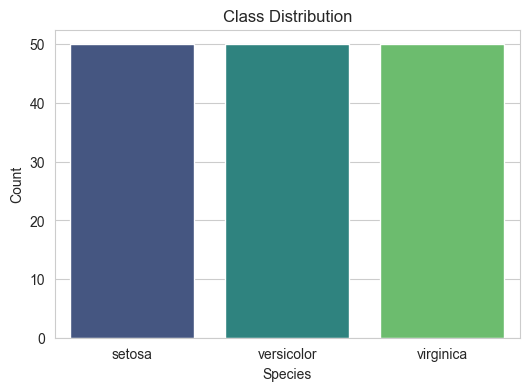

In [10]:
class_counts = df_iris['species'].value_counts().reset_index()
class_counts.columns = ['species', 'count']

plt.figure(figsize=(6,4))

sns.barplot(
    data=class_counts,
    x='species',
    y='count',
    hue='species',
    palette='viridis',
    legend=False
)

plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

### **Pairwise Feature Relationship Analysis**

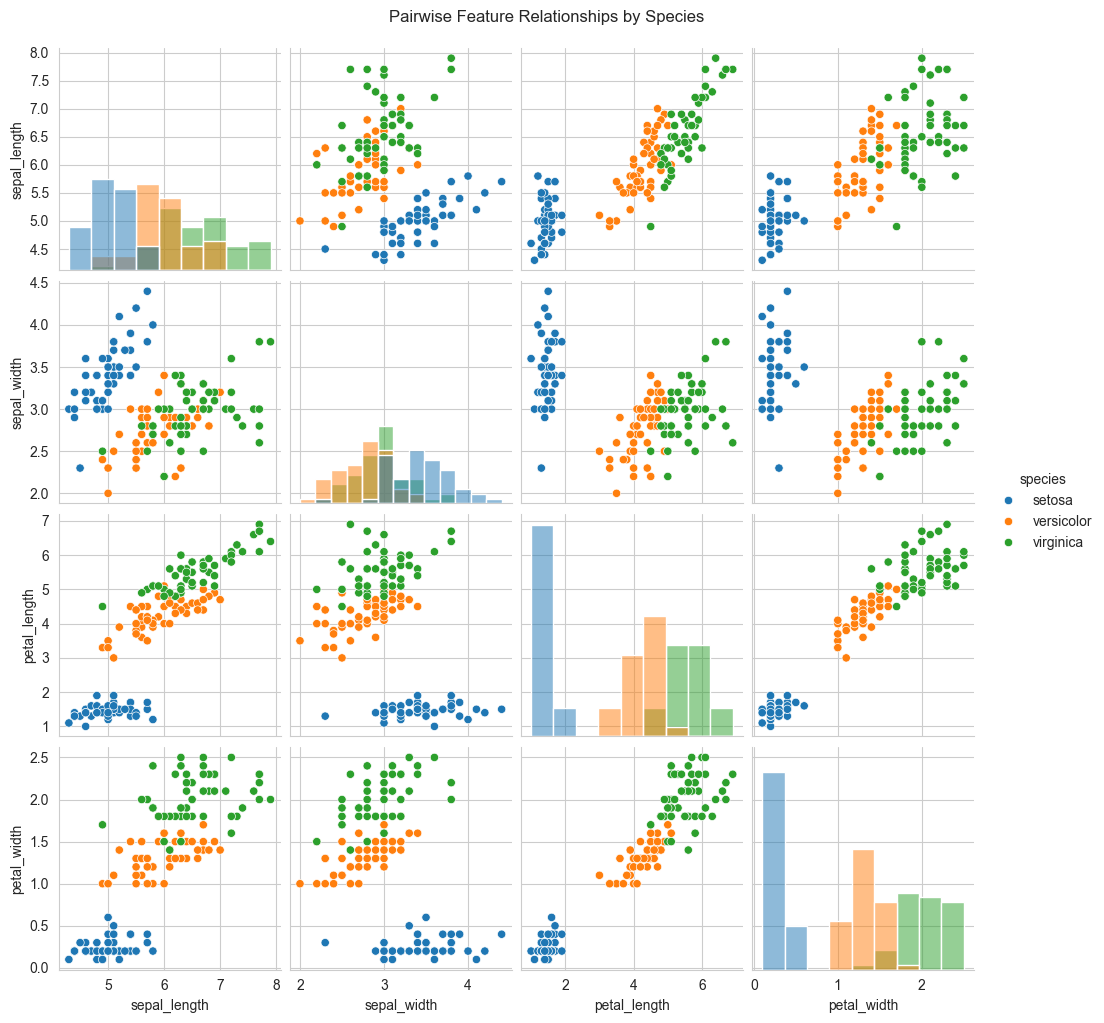

In [11]:
sns.pairplot(df_iris, hue='species', diag_kind='hist')
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()

### **Boxplot Analysis (Outlier Detection)**

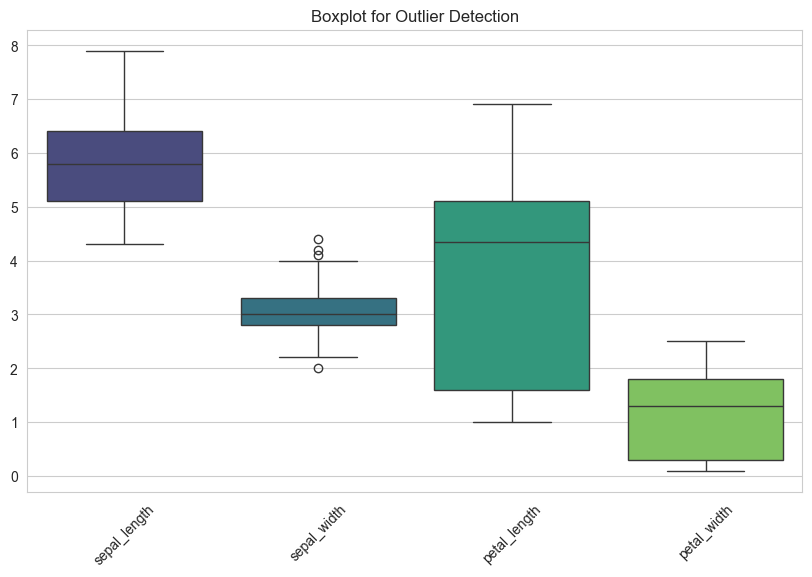

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_iris, palette="viridis")

plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)

plt.show()

### **Outlier Detection - Numeric Measure**

In [13]:
# Select only numeric columns
df_numeric = df_iris.select_dtypes(include='number')

# Q1, Q3, IQR
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Outlier detection
outliers = (df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))

print(outliers.sum())

sepal_length    0
sepal_width     4
petal_length    0
petal_width     0
dtype: int64


### **Feature Relationship Analysis with Class-Based Segmentation**

#### **Sepal - Petal Length Wise**

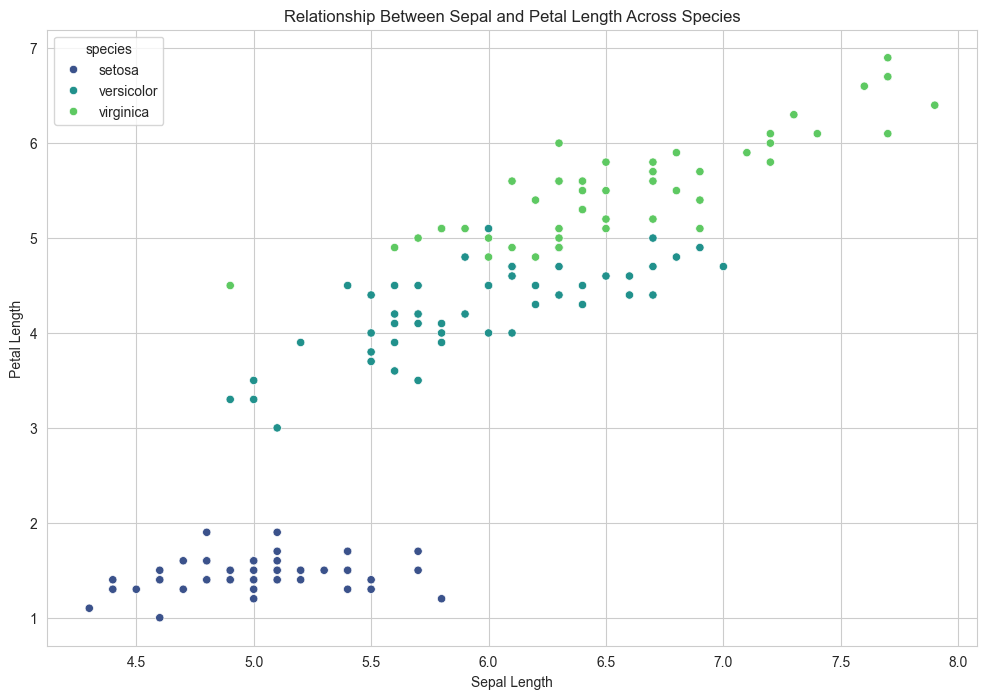

In [14]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df_iris,
    x='sepal_length',
    y='petal_length',
    hue='species',
    palette='viridis'
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Relationship Between Sepal and Petal Length Across Species")
plt.show()

#### **Sepal - Petal Width Wise**

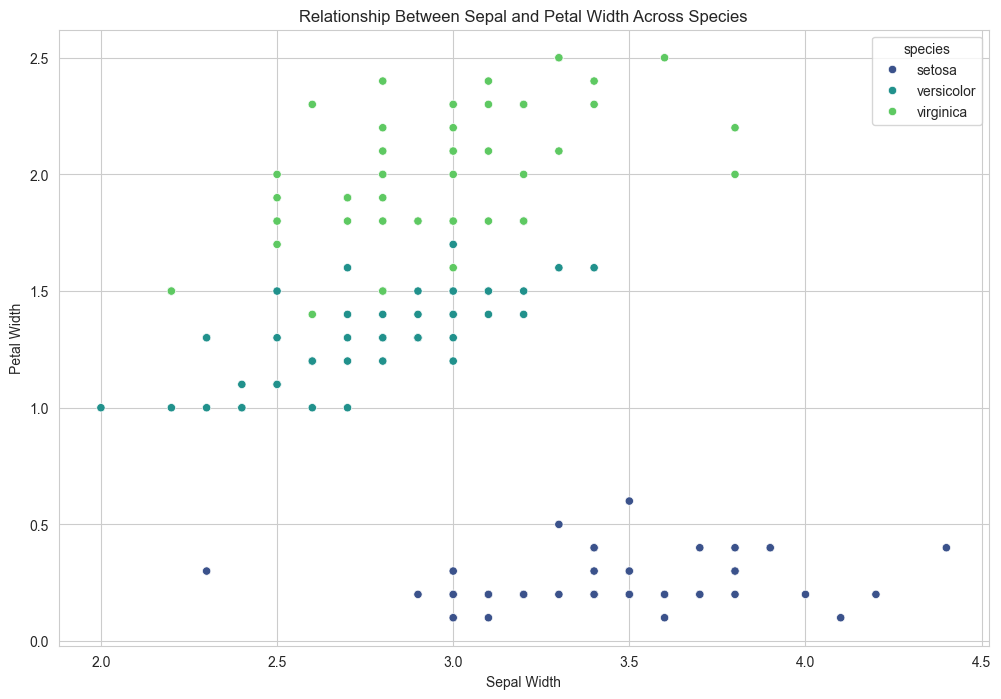

In [15]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df_iris,
    x='sepal_width',
    y='petal_width',
    hue='species',
    palette='viridis'
)

plt.xlabel("Sepal Width")
plt.ylabel("Petal Width")
plt.title("Relationship Between Sepal and Petal Width Across Species")
plt.show()

### **Regression Relationship (Trend Analysis)**

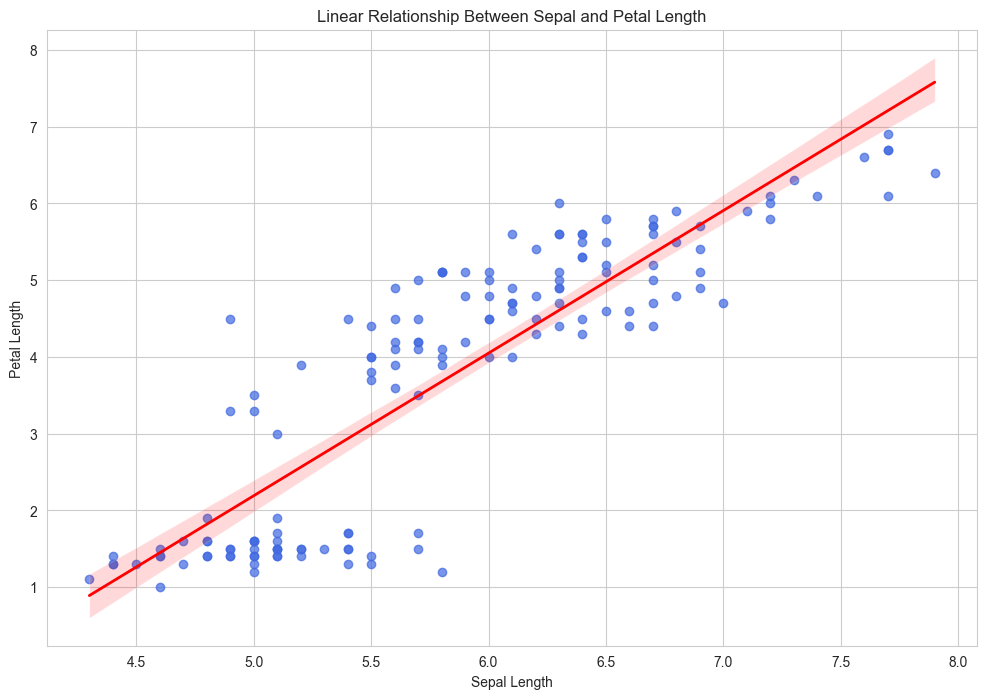

In [16]:
plt.figure(figsize=(12,8))

sns.regplot(
    data=df_iris,
    x='sepal_length',
    y='petal_length',
    line_kws={'color': 'red', 'linewidth': 2},
    scatter_kws={'color': 'royalblue', 'alpha': 0.7}
)

plt.title("Linear Relationship Between Sepal and Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.show()

### **Joint Distribution Analysis of Sepal and Petal Length Across Iris Species**

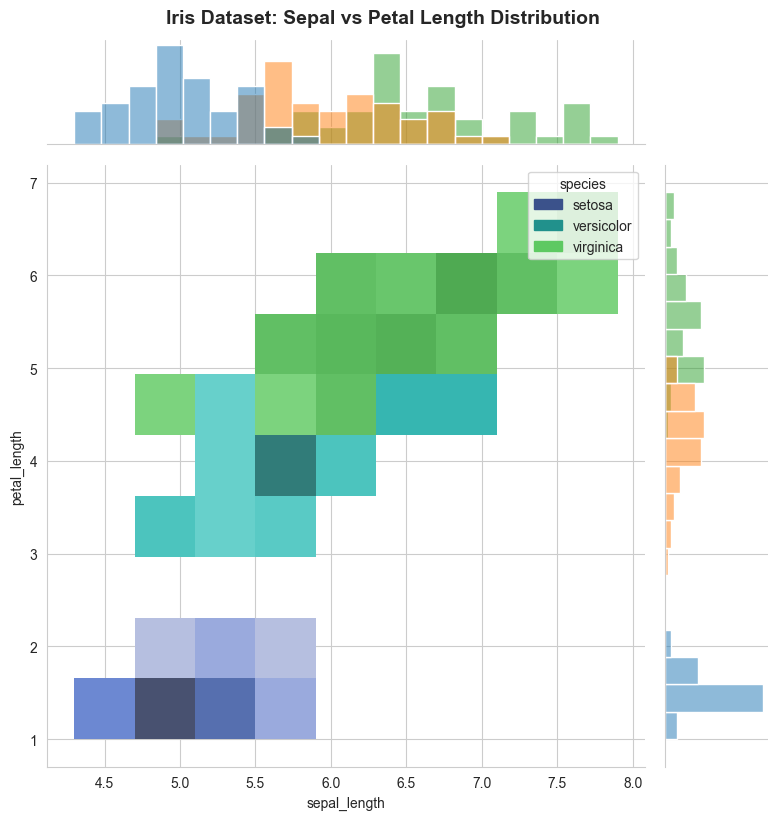

In [17]:
sns.jointplot(
    data=df_iris,
    x='sepal_length',
    y='petal_length',
    hue='species',
    kind='hist',
    palette='viridis',
    height=8,
    ratio=5,
    marginal_kws=dict(bins=20, fill=True)
)

plt.suptitle(
    "Iris Dataset: Sepal vs Petal Length Distribution",
    y=1.02,
    fontsize=14,
    fontweight='bold'
)

plt.show()

### **Feature Relationship Mapping Between Sepal and Petal Length**

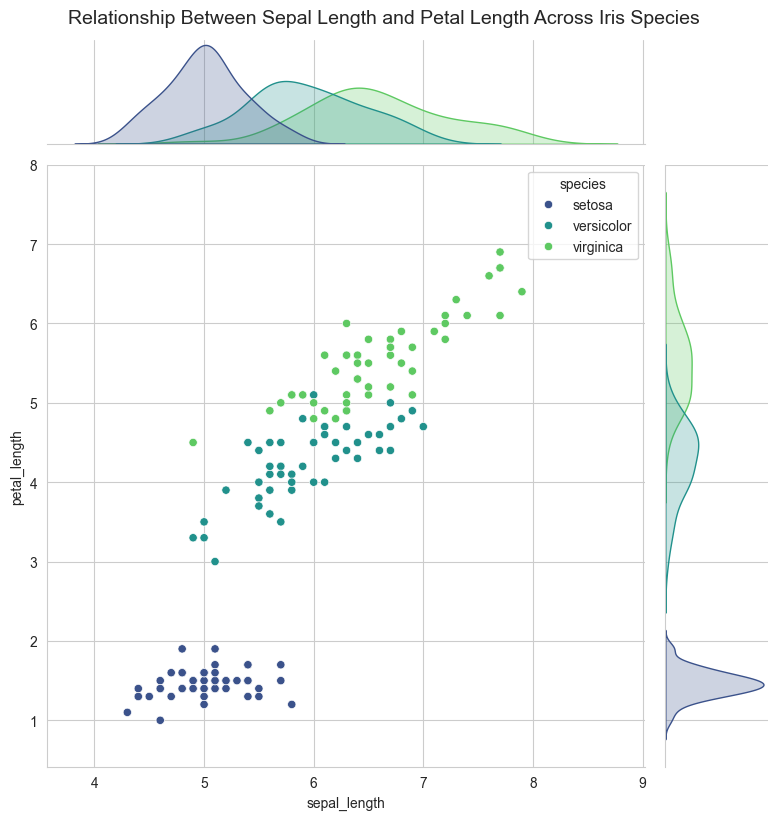

In [18]:
sns.jointplot(
    data=df_iris,
    x='sepal_length',
    y='petal_length',
    hue='species',
    kind='scatter',
    palette='viridis',
    height=8,      
    ratio=5        
)

plt.suptitle(
    "Relationship Between Sepal Length and Petal Length Across Iris Species",
    y=1.02,
    fontsize=14
)

plt.show()

### **Correlation Analysis (Feature Dependency)**

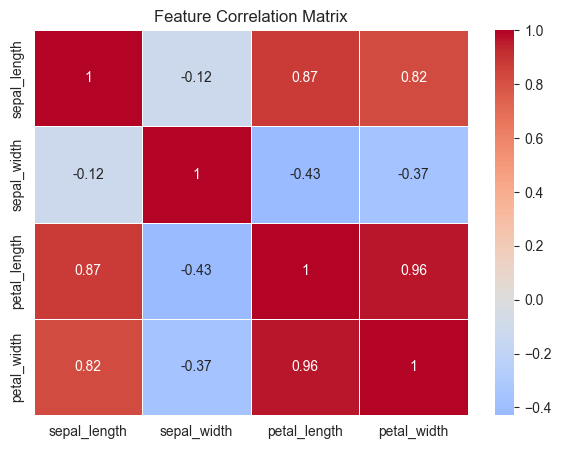

In [19]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df_iris.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

### **Comparative Analysis of Average Feature Values Across Species**

In [20]:
grouped = df_iris.groupby('species').mean()
display(grouped)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


### **Feature Engineering: Creation of Petal and Sepal Aspect Ratios**

In [21]:
df_iris['petal_ratio'] = df_iris['petal_length'] / df_iris['petal_width']
df_iris['sepal_ratio'] = df_iris['sepal_length'] / df_iris['sepal_width']

display(df_iris.head())

,sepal_length,sepal_width,petal_length,petal_width,species,petal_ratio,sepal_ratio
0,5.1,3.5,1.4,0.2,setosa,7.0,1.457143
1,4.9,3.0,1.4,0.2,setosa,7.0,1.633333
2,4.7,3.2,1.3,0.2,setosa,6.5,1.468750
3,4.6,3.1,1.5,0.2,setosa,7.5,1.483871
4,5.0,3.6,1.4,0.2,setosa,7.0,1.388889


### **Comparative Distribution of Iris Features Segmented by Species**

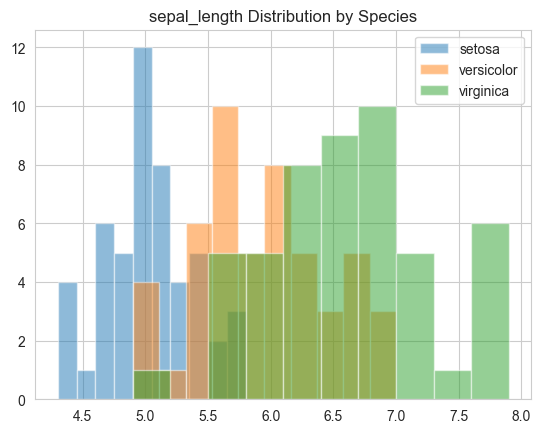

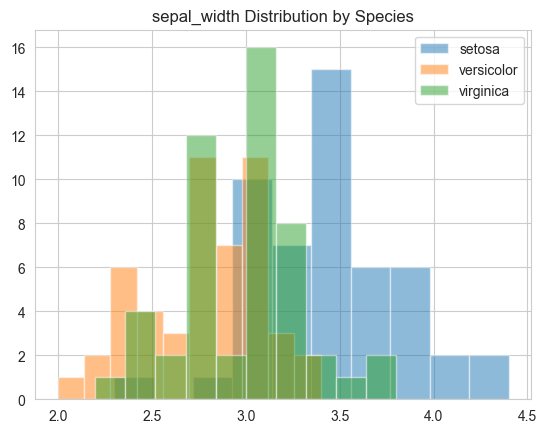

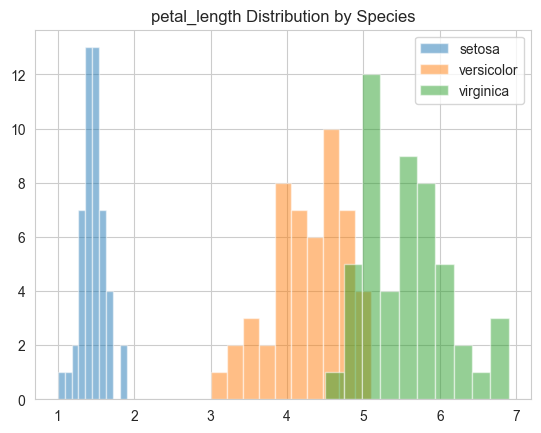

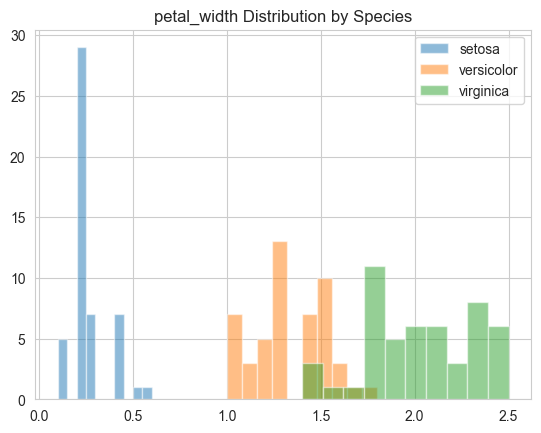

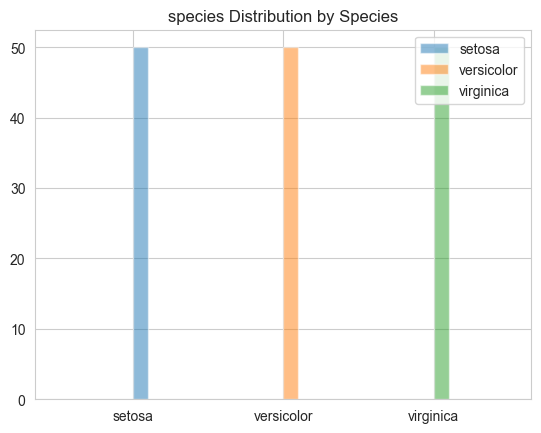

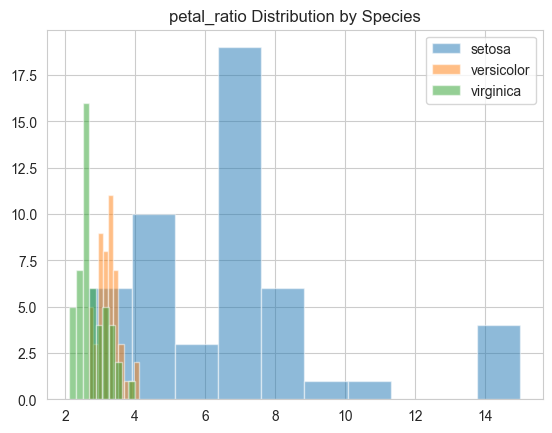

In [22]:
for col in df_iris.columns[:-1]:
    plt.figure()
    for species in df_iris['species'].unique():
        subset = df_iris[df_iris['species'] == species]
        plt.hist(subset[col], alpha=0.5, label=species)
    plt.legend()
    plt.title(f"{col} Distribution by Species")
    plt.show()

### **Quantifying Feature Spread Across Iris Dataset Using Variance Metrics**

In [23]:
display(
    df_iris.var(numeric_only=True)
    .to_frame(name="Variance")
    .style.format("{:.4f}")
)

,Variance
sepal_length,0.6857
sepal_width,0.1900
petal_length,3.1163
petal_width,0.5810
petal_ratio,6.1983
sepal_ratio,0.1604


### **Assessment of Feature Distribution Shape Using Skewness and Kurtosis**

In [24]:
display(df_iris.skew(numeric_only=True).to_frame(name="Skewness").style.format("{:.4f}"))
display(df_iris.kurtosis(numeric_only=True).to_frame(name="Kurtosis").style.format("{:.4f}"))

,Skewness
sepal_length,0.3149
sepal_width,0.3190
petal_length,-0.2749
petal_width,-0.1030
petal_ratio,2.2779
sepal_ratio,0.0186


,Kurtosis
sepal_length,-0.5521
sepal_width,0.2282
petal_length,-1.4021
petal_width,-1.3406
petal_ratio,5.9304
sepal_ratio,-0.8166


### **Visualization of Feature Distributions with Skewness and Kurtosis Annotation**

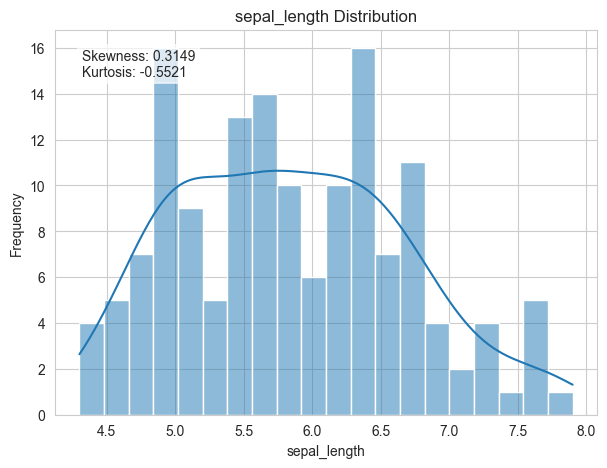

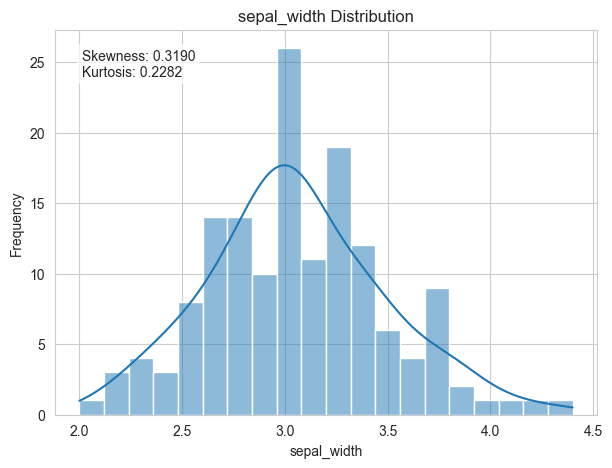

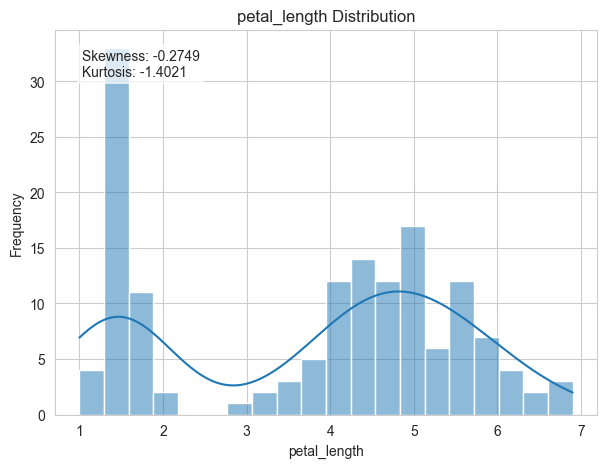

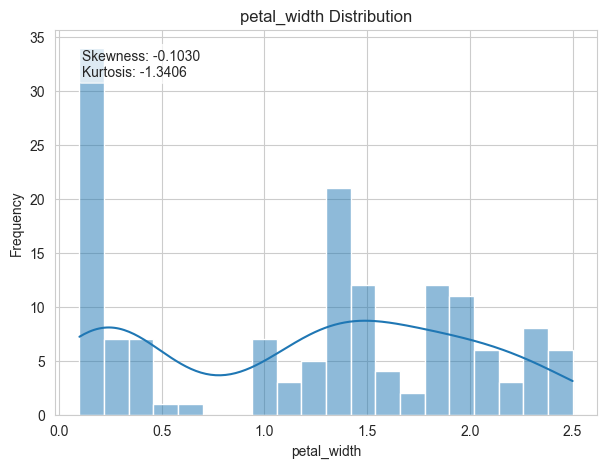

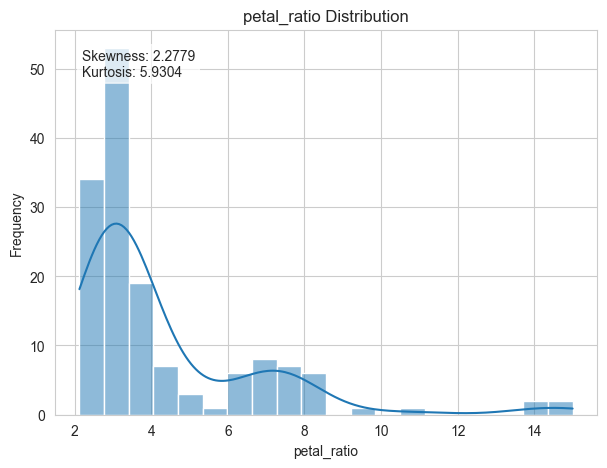

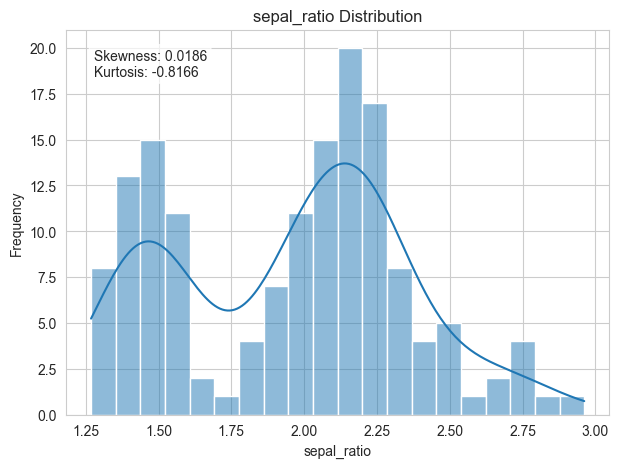

In [25]:
for col in df_iris.select_dtypes(include='number').columns:
    skew_val = df_iris[col].skew()
    kurt_val = df_iris[col].kurtosis()

    plt.figure(figsize=(7,5))
    sns.histplot(df_iris[col], kde=True, bins=20)

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.text(
        0.05, 0.95,
        f"Skewness: {skew_val:.4f}\nKurtosis: {kurt_val:.4f}",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

    plt.show()

# **Final Conclusion**

### *The Iris dataset is clean, balanced, and highly structured. EDA reveals that petal features are the most powerful predictors, while sepal features contribute less to class separation. Overall, it’s an excellent dataset for modeling but far simpler than real-world data, which is usually noisier and more complex.*